In [22]:
from typing_extensions import TypedDict
from langgraph.graph import START,END,StateGraph
from IPython.display import Image, display

In [1]:
class State(TypedDict):
  user_text : str
  tokenized_text : list[str]
  num_of_char_in_tokens : list[int]
  num_of_tokens:int

In [3]:
def tokenize_text(state:State):
  user_text=state['user_text']
  return {'tokenized_text' : user_text.split()}

In [8]:
def num_of_char_in_tokens(state : State):
  tokenized_text=state['tokenized_text']
  num_of_char_in_tokens=[]
  for i in tokenized_text:
    num_of_char_in_tokens.append(len(i))
  return {'num_of_char_in_tokens' : num_of_char_in_tokens}

In [10]:
def total_num_of_tokens(state : State) :
  tokenized_text=state['tokenized_text']

  return {'num_of_tokens' : len(tokenized_text)}


In [12]:
builder=StateGraph(State)

In [13]:
builder.add_node("tokenize_text" ,  tokenize_text)
builder.add_node("num_of_char_in_tokens" , num_of_char_in_tokens)
builder.add_node("total_num_of_tokens" , total_num_of_tokens)


In [14]:
builder.add_edge(START,"tokenize_text")
builder.add_edge("tokenize_text" , "num_of_char_in_tokens")
builder.add_edge("tokenize_text","total_num_of_tokens")
builder.add_edge("num_of_char_in_tokens",END)
builder.add_edge("total_num_of_tokens",END)

In [15]:
graph=builder.compile()

In [21]:
results=graph.invoke(
    {"user_text" : "today i will attend monday night raw"}
)

In [18]:
results

{'user_text': 'today i will attend monday night raw',
 'tokenized_text': ['today', 'i', 'will', 'attend', 'monday', 'night', 'raw'],
 'num_of_char_in_tokens': [5, 1, 4, 6, 6, 5, 3],
 'num_of_tokens': 7}

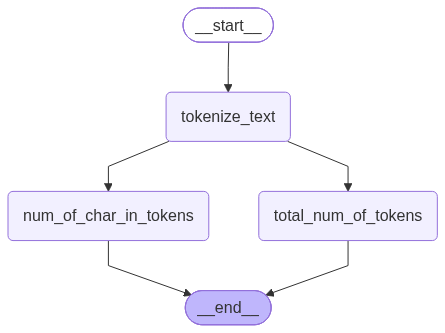

In [23]:
display(Image(graph.get_graph().draw_mermaid_png()))